# Hypothesis testing on real data: do penguin species differ?

*Part 2 · Lesson 13 · another dataset  ·  data: Palmer Penguins*

*↩ A companion to [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb).*

**↩ Back:** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](13-hypothesis-testing~the-code.ipynb)

The core lesson built its "null world" by hand — it took a known population and *slid* it sideways until
its mean matched a made-up claim, then drew samples from that synthetic world. That's a great way to
*see* the machinery, but it can feel abstract: we invented both the claim and the world.

Here we change nothing about the **logic** and everything about the **source**. Instead of a simulated
population we use a real dataset — the weights of three penguin species — and let *nature* hand us the
two cases that matter. Two of the species (**Adelie** and **Chinstrap**) turn out to weigh almost
exactly the same: a genuine **near-null**, where the honest answer is "no real difference." The third
(**Gentoo**) is dramatically heavier: a genuine **effect** that no test could miss. So you get to watch a
real *"fail to reject"* and a real *"reject"* sitting side by side, and then see the famous 5% false-alarm
rate emerge straight out of real penguin weights. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats        # the two-sample t-test lives here
sl.use_course_style()

PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
pen = sl.load_csv('penguins.csv', url=PENGUINS_URL).dropna(subset=['body_mass_g', 'species'])

# Pull each species' body mass (grams) into its own array.
adelie    = pen.loc[pen['species'] == 'Adelie',    'body_mass_g'].to_numpy()
chinstrap = pen.loc[pen['species'] == 'Chinstrap', 'body_mass_g'].to_numpy()
gentoo    = pen.loc[pen['species'] == 'Gentoo',    'body_mass_g'].to_numpy()

for name, arr in [('Adelie', adelie), ('Chinstrap', chinstrap), ('Gentoo', gentoo)]:
    print(f'{name:9s}  n = {len(arr):3d}   mean = {arr.mean():6.1f} g   sd = {arr.std(ddof=1):5.1f} g')

Adelie     n = 151   mean = 3700.7 g   sd = 458.6 g
Chinstrap  n =  68   mean = 3733.1 g   sd = 384.3 g
Gentoo     n = 123   mean = 5076.0 g   sd = 504.1 g


## 1) The question, and the two hypotheses

We're comparing the **average body mass** of two penguin species at a time. The question is always the
same shape: *"do these two groups really differ, or could the gap we see just be the luck of which
penguins happened to get weighed?"* Every hypothesis test names **two** competing statements:

- **Null hypothesis $H_0$** — the "nothing special" claim: the two species have the **same** true mean
  weight, $H_0:\ \mu_A = \mu_B$ (equivalently, the difference $\mu_A - \mu_B = 0$). The null is always
  the precise, boring equality — it's the world we'll *simulate*.
- **Alternative hypothesis $H_a$** — what we suspect instead: the means are **different**,
  $H_a:\ \mu_A \neq \mu_B$. This is **two-sided** (we'd care about a difference in either direction).

A test never *proves* $H_0$. Like a courtroom, it presumes the null ("the two species are the same") and
asks whether the evidence is strong enough to **reject** it. Let's look at the raw gaps first.

In [2]:
diff_AC = adelie.mean() - chinstrap.mean()    # Adelie vs Chinstrap
diff_AG = adelie.mean() - gentoo.mean()        # Adelie vs Gentoo

print(f'Adelie mean    = {adelie.mean():.1f} g')
print(f'Chinstrap mean = {chinstrap.mean():.1f} g')
print(f'Gentoo mean    = {gentoo.mean():.1f} g\n')
print(f'Adelie - Chinstrap = {diff_AC:+.1f} g   <- tiny gap. Real, or just chance?')
print(f'Adelie - Gentoo    = {diff_AG:+.1f} g   <- huge gap. Surely real... but let us check.')

Adelie mean    = 3700.7 g
Chinstrap mean = 3733.1 g
Gentoo mean    = 5076.0 g

Adelie - Chinstrap = -32.4 g   <- tiny gap. Real, or just chance?
Adelie - Gentoo    = -1375.4 g   <- huge gap. Surely real... but let us check.


A **32-gram** gap between Adelie and Chinstrap is the weight of a few paperclips — on penguins that weigh
nearly four kilograms. The **1,375-gram** gap to Gentoo is more than a third of a penguin. Our eyes
already suspect the first is noise and the second is real; the rest of the lesson makes that suspicion
*quantitative*, and shows you exactly how a test reaches the same verdict.

## 2) Building the null world from real weights — the permutation test

In the core lesson we *built* a null population by shifting a known one. With real groups there's an even
more direct trick, and it needs **no formula and no assumed bell curve**: the **permutation test**.

Here's the idea. *If the null were true* — if species labels made no difference to weight — then the
"Adelie" and "Chinstrap" tags are just arbitrary stickers on one big pooled bag of penguins. So we can
build the null world by hand:

1. **Pool** both groups into one bag of weights.
2. **Shuffle** the labels: randomly deal the weights back out into a fake "Adelie" group and a fake
   "Chinstrap" group of the original sizes.
3. **Recompute** the difference in means for that shuffled split.

Repeat thousands of times and you get the **null distribution**: every difference the data could produce
*if the labels truly didn't matter*. The observed gap is then judged against that distribution.

In [3]:
def permutation_null(a, b, n_perm=20000, seed=0):
    # Build the null distribution of (mean a - mean b) by shuffling the pooled labels.
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([a, b])
    n_a = len(a)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)                       # deal the labels at random
        diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    return diffs

null_AC = permutation_null(adelie, chinstrap, seed=1)
print(f'Built {len(null_AC):,} shuffled "no-difference" worlds for Adelie vs Chinstrap.')
print(f'Mean of the null differences: {null_AC.mean():+.2f} g  (centered on 0, as the null demands)')
print(f'Spread (sd) of the null differences: {null_AC.std(ddof=0):.1f} g')

Built 20,000 shuffled "no-difference" worlds for Adelie vs Chinstrap.
Mean of the null differences: +0.40 g  (centered on 0, as the null demands)
Spread (sd) of the null differences: 63.4 g


## 3) Demo 1 — the near-null: Adelie vs Chinstrap

Now the **p-value**, the heart of the whole method:

> *If the two species truly had the same mean weight, how often would pure label-shuffling luck produce a
> gap at least as big as the **32 g** we actually saw?*

That fraction — the share of the null distribution as far from 0 as our observed gap (in *either*
direction, because $H_a$ is two-sided) — **is** the p-value. A big p-value means "the null world coughs
up gaps like ours all the time, so ours isn't surprising."

In [4]:
p_AC = np.mean(np.abs(null_AC) >= np.abs(diff_AC))
print(f'Observed Adelie - Chinstrap gap : {diff_AC:+.1f} g')
print(f'Permutation p-value             : {p_AC:.4f}')
print(f'(That is the share of {len(null_AC):,} shuffled worlds with |gap| >= {abs(diff_AC):.1f} g.)')
print('\nA gap this small turns up by chance roughly 6 times in 10 -- not surprising at all.')

Observed Adelie - Chinstrap gap : -32.4 g
Permutation p-value             : 0.6091
(That is the share of 20,000 shuffled worlds with |gap| >= 32.4 g.)

A gap this small turns up by chance roughly 6 times in 10 -- not surprising at all.


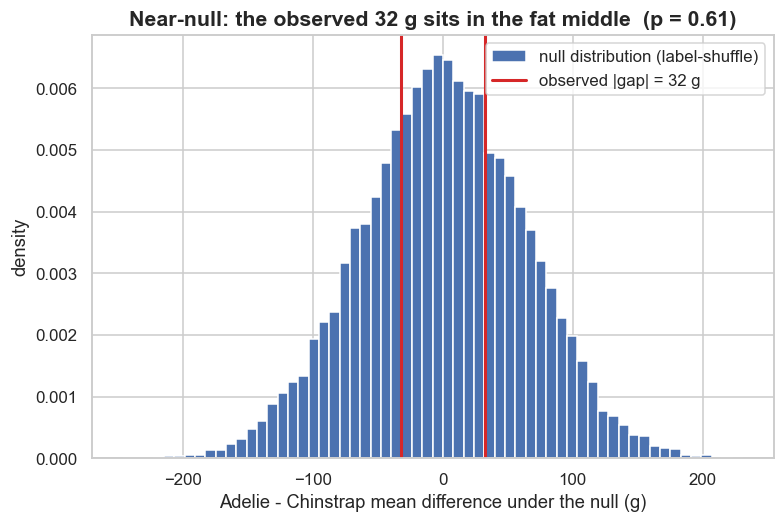

In [5]:
fig, ax = plt.subplots()
ax.hist(null_AC, bins=60, color='#4c72b0', edgecolor='white', density=True,
        label='null distribution (label-shuffle)')
for sign in (-1, 1):
    ax.axvline(sign * abs(diff_AC), color='#d62728', lw=2,
               label='observed |gap| = 32 g' if sign == 1 else None)
ax.set_xlabel('Adelie - Chinstrap mean difference under the null (g)')
ax.set_ylabel('density')
ax.set_title(f'Near-null: the observed 32 g sits in the fat middle  (p = {p_AC:.2f})')
ax.legend(); plt.show()

The red lines (our observed $\pm 32$ g) land smack in the **fat middle** of the pile. The null world
produces gaps this big — and far bigger — routinely. With $p \approx 0.59 > 0.05$ we **fail to reject
$H_0$**: there is no convincing evidence that Adelie and Chinstrap differ in weight. The honest summary
is *"this 32 g gap could easily be chance,"* **not** *"we proved they weigh the same."*

The textbook **Welch two-sample t-test** (which reads the tail off a smooth $t$-curve instead of counting
shuffles) reaches the same verdict in one line — and the two p-values should be close.

In [6]:
welch_AC = stats.ttest_ind(adelie, chinstrap, equal_var=False)   # Welch: no equal-variance assumption
print(f'permutation p-value      = {p_AC:.4f}')
print(f'Welch t-test p-value     = {welch_AC.pvalue:.4f}')
print(f'Welch t statistic        = {welch_AC.statistic:.3f}')
print('\nBoth say the same thing: with p well above 0.05, FAIL TO REJECT -- no real difference shown.')

permutation p-value      = 0.6091
Welch t-test p-value     = 0.5879
Welch t statistic        = -0.543

Both say the same thing: with p well above 0.05, FAIL TO REJECT -- no real difference shown.


## 4) Demo 2 — the glaring effect: Adelie vs Gentoo

Exactly the same machinery, a completely different verdict. Gentoos outweigh Adelies by about
**1,375 g**. We rebuild the null world by shuffling *these* two groups' labels and ask the same question:
how often does label-luck alone manufacture a gap that enormous?

In [7]:
null_AG = permutation_null(adelie, gentoo, seed=2)
p_AG = np.mean(np.abs(null_AG) >= np.abs(diff_AG))

print(f'Observed Adelie - Gentoo gap : {diff_AG:+.1f} g')
print(f'Null gaps range only from {null_AG.min():.0f} g to {null_AG.max():.0f} g.')
print(f'Permutation p-value          : {p_AG:.5f}  (0 means: not ONE shuffle out of {len(null_AG):,} matched it)')

welch_AG = stats.ttest_ind(adelie, gentoo, equal_var=False)
print(f'Welch t-test p-value         : {welch_AG.pvalue:.2e}   (essentially zero)')
print(f'Welch t statistic            : {welch_AG.statistic:.1f}   (about 23 standard errors out!)')

Observed Adelie - Gentoo gap : -1375.4 g
Null gaps range only from -365 g to 439 g.
Permutation p-value          : 0.00000  (0 means: not ONE shuffle out of 20,000 matched it)
Welch t-test p-value         : 7.71e-65   (essentially zero)
Welch t statistic            : -23.4   (about 23 standard errors out!)


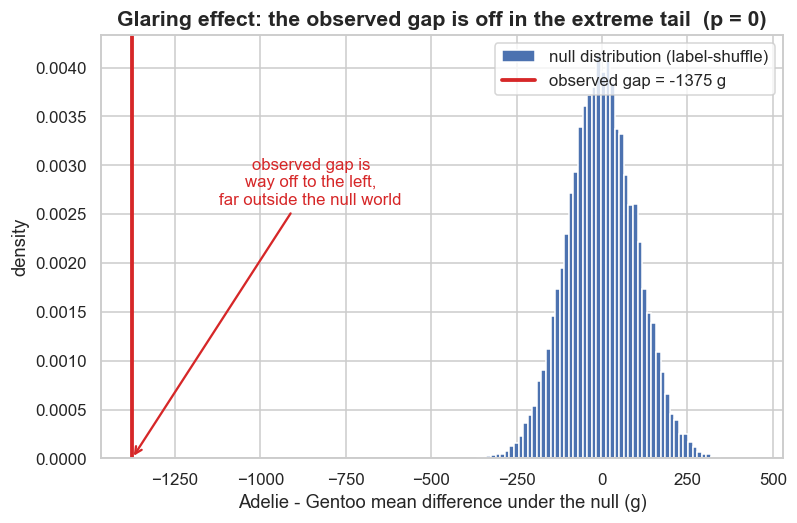

In [8]:
fig, ax = plt.subplots()
ax.hist(null_AG, bins=60, color='#4c72b0', edgecolor='white', density=True,
        label='null distribution (label-shuffle)')
ax.axvline(diff_AG, color='#d62728', lw=2.5, label=f'observed gap = {diff_AG:.0f} g')
ax.annotate('observed gap is\nway off to the left,\nfar outside the null world',
            xy=(diff_AG, 0), xytext=(diff_AG * 0.62, ax.get_ylim()[1] * 0.6),
            color='#d62728', ha='center',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))
ax.set_xlabel('Adelie - Gentoo mean difference under the null (g)')
ax.set_ylabel('density')
ax.set_title('Glaring effect: the observed gap is off in the extreme tail  (p = 0)')
ax.legend(loc='upper right'); plt.show()

The null world's gaps huddle within roughly $\pm 200$ g of zero; our observed $-1{,}375$ g is *miles*
outside it — so far that not a single one of 20,000 shuffles came close. With $p$ essentially **0** we
**reject $H_0$ decisively**: the Adelie–Gentoo weight difference is real, not chance.

**Two real datasets, same method, opposite verdicts.** That side-by-side is the whole point of grounding
this in nature instead of a simulated population: one comparison *should* fail to reject and one *should*
reject, and the machinery sorts them correctly without ever being told the answer.

## 5) The decision rule, and what a p-value is (and isn't)

Before peeking at the data you pick a **significance level $\alpha$** — the false-alarm risk you'll
accept. The convention is $\alpha = 0.05$. The rule:

- **$p \le \alpha$** → **reject $H_0$** (the gap is too surprising for the null — *statistically
  significant*). That's Adelie vs Gentoo.
- **$p > \alpha$** → **fail to reject $H_0$** (not enough evidence; the null survives, *un*-proven).
  That's Adelie vs Chinstrap.

A p-value **is** *the probability of a gap at least this extreme **if $H_0$ were true*** — surprise under
the null. What it is **NOT**:

- ❌ **not** "the probability the species are the same." ($p$ is $P(\text{data}\mid H_0)$, never
  $P(H_0\mid\text{data})$.)
- ❌ **not** an **effect size**. With a huge sample even a 5 g difference could be "significant." Our
  *story* here is driven by genuinely different effect sizes (32 g vs 1,375 g), but in general a small
  $p$ means "probably real," not "big or important."
- ❌ "Fail to reject" is **not** "proved $H_0$." Adelie and Chinstrap might differ by a gram or two; this
  test simply can't tell, and says so.

In [9]:
alpha = 0.05
for label, p in [('Adelie vs Chinstrap', welch_AC.pvalue), ('Adelie vs Gentoo', welch_AG.pvalue)]:
    decision = 'REJECT H0  (significant difference)' if p <= alpha else 'FAIL TO REJECT H0  (no difference shown)'
    print(f'{label:22s}  p = {p:9.2e}   ->  {decision}')

Adelie vs Chinstrap     p =  5.88e-01   ->  FAIL TO REJECT H0  (no difference shown)
Adelie vs Gentoo        p =  7.71e-65   ->  REJECT H0  (significant difference)


## 6) Type I error — the price of a 5% threshold, measured on real penguins

A test makes a yes/no call about an unknown truth, so there are exactly **two** ways to blunder:

| | $H_0$ really **true** (no difference) | $H_0$ really **false** (a real difference) |
|---|---|---|
| **We reject $H_0$** | ❌ **Type I error** (false alarm) | ✅ correct (a "hit") |
| **We fail to reject** | ✅ correct | ❌ **Type II error** (a miss) |

- **Type I error** = rejecting a *true* null (crying wolf). Its long-run rate **is** $\alpha$.
- **Type II error** = missing a *real* difference. Its rate is **$\beta$**.
- **Power $= 1 - \beta$** = the chance of correctly catching a real difference.

Can we *watch* the Type I rate emerge from real data? Yes — we need a comparison where $H_0$ is
**guaranteed true**, and the penguins hand us one for free: take a **single** species (all the Adelies),
split its weights at random into two arbitrary halves, and test those halves against each other. They
came from the *same* bag, so any "difference" is pure noise — the null is true *by construction*. Do it
2,000 times at $\alpha = 0.05$ and count how often the test falsely cries "significant!"

In [10]:
def type_I_rate(group, n_trials=2000, alpha=0.05, seed=0):
    # Split ONE group randomly in half many times and test the halves. H0 is TRUE every time.
    rng = np.random.default_rng(seed)
    half = len(group) // 2
    false_alarms = 0
    for _ in range(n_trials):
        idx = rng.permutation(len(group))                 # a fresh random shuffle
        left, right = group[idx[:half]], group[idx[half:]]
        if stats.ttest_ind(left, right, equal_var=False).pvalue <= alpha:
            false_alarms += 1
    return false_alarms / n_trials

rate = type_I_rate(adelie, n_trials=2000, alpha=0.05, seed=3)
print(f'Split the Adelies randomly in two and tested them 2,000 times (H0 TRUE every time).')
print(f'Falsely "significant" at alpha = 0.05 : {rate:.3f}')
print(f'Right around the {0.05:.2f} we signed up for -- false positives are the PRICE of a 5% threshold.')

Split the Adelies randomly in two and tested them 2,000 times (H0 TRUE every time).
Falsely "significant" at alpha = 0.05 : 0.045
Right around the 0.05 we signed up for -- false positives are the PRICE of a 5% threshold.


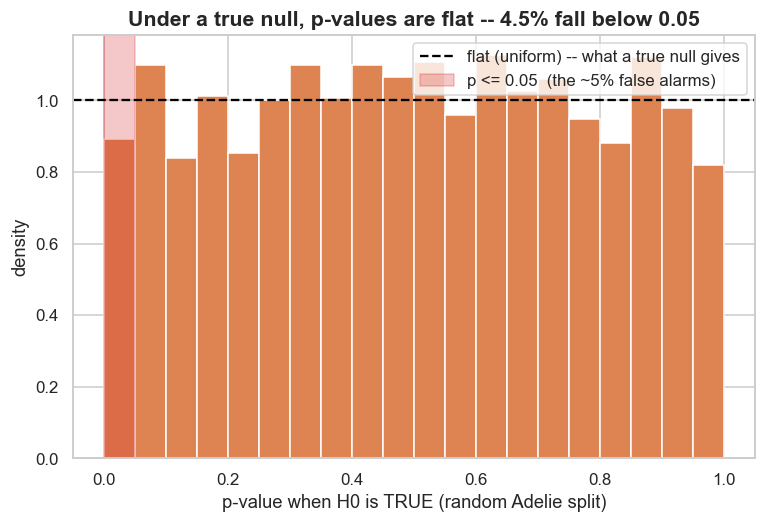

In [11]:
# The flip side: when H0 is true, p-values are spread EVENLY across 0..1.
# A flat histogram with ~5% of its area left of 0.05 is exactly why the false-alarm rate is ~5%.
rng = np.random.default_rng(5)
half = len(adelie) // 2
pvals_null = []
for _ in range(3000):
    idx = rng.permutation(len(adelie))
    pvals_null.append(stats.ttest_ind(adelie[idx[:half]], adelie[idx[half:]], equal_var=False).pvalue)
pvals_null = np.array(pvals_null)

fig, ax = plt.subplots()
ax.hist(pvals_null, bins=20, range=(0, 1), color='#dd8452', edgecolor='white', density=True)
ax.axhline(1.0, color='black', lw=1.5, ls='--', label='flat (uniform) -- what a true null gives')
ax.axvspan(0, 0.05, color='#d62728', alpha=0.25, label='p <= 0.05  (the ~5% false alarms)')
ax.set_xlabel('p-value when H0 is TRUE (random Adelie split)')
ax.set_ylabel('density')
ax.set_title(f'Under a true null, p-values are flat -- {np.mean(pvals_null <= 0.05) * 100:.1f}% fall below 0.05')
ax.legend(); plt.show()

When the null is true the p-value is equally likely to be anything from 0 to 1 — a **flat** histogram. The
slice below 0.05 is, by definition, about 5% of the area, and that slice **is** the Type I error rate. You
don't *avoid* false alarms by choosing $\alpha = 0.05$; you *choose* their long-run rate to be 5%. Set
`alpha = 0.01` and that shaded slice — and the false-alarm rate — shrinks toward 1%.

## 7) Power — why we caught Gentoo but couldn't catch a tiny gap

**Power** is the happy opposite of a Type II error: when there *is* a real difference, how often does the
test actually notice? Two of our three comparisons sit at opposite extremes of power, and we can estimate
each by resampling the real penguins (drawing fresh samples *with replacement*, treating each species as
its own little population) and seeing how often the test rejects.

In [12]:
def power_estimate(a, b, n_each, n_trials=2000, alpha=0.05, seed=0):
    # How often does the test reject when comparing fresh resamples of a vs b? (= power.)
    rng = np.random.default_rng(seed)
    rejects = 0
    for _ in range(n_trials):
        sa = rng.choice(a, size=n_each, replace=True)
        sb = rng.choice(b, size=n_each, replace=True)
        if stats.ttest_ind(sa, sb, equal_var=False).pvalue <= alpha:
            rejects += 1
    return rejects / n_trials

# Use a common modest sample size so the comparison is about the EFFECT, not the n.
n_each = 40
power_AG = power_estimate(adelie, gentoo,    n_each, seed=6)   # huge ~1375 g effect
power_AC = power_estimate(adelie, chinstrap, n_each, seed=7)   # tiny ~32 g effect
print(f'Power to detect the HUGE Adelie-vs-Gentoo gap   (n={n_each} each): {power_AG:.3f}  ~ certain to catch')
print(f'Power to detect the TINY Adelie-vs-Chinstrap gap (n={n_each} each): {power_AC:.3f}  ~ barely better than guessing')

Power to detect the HUGE Adelie-vs-Gentoo gap   (n=40 each): 1.000  ~ certain to catch
Power to detect the TINY Adelie-vs-Chinstrap gap (n=40 each): 0.061  ~ barely better than guessing


The Gentoo gap is caught essentially **100%** of the time — a difference that large is impossible to
miss. The Chinstrap gap is detected only a little more often than the 5% false-alarm floor: with a true
effect of just 32 g, the test is mostly **blind** to it. That low power is *exactly* why we failed to
reject in section 3 — and a crucial lesson: *"fail to reject" can mean "no real effect" **or** "a real
effect too small for this much data to see."* You can't tell which from a single non-significant result.

The two levers that buy power are **a bigger true effect** and **more data**. Let's hold the (tiny)
Chinstrap effect fixed and grow the sample size — power should climb as $n$ rises.

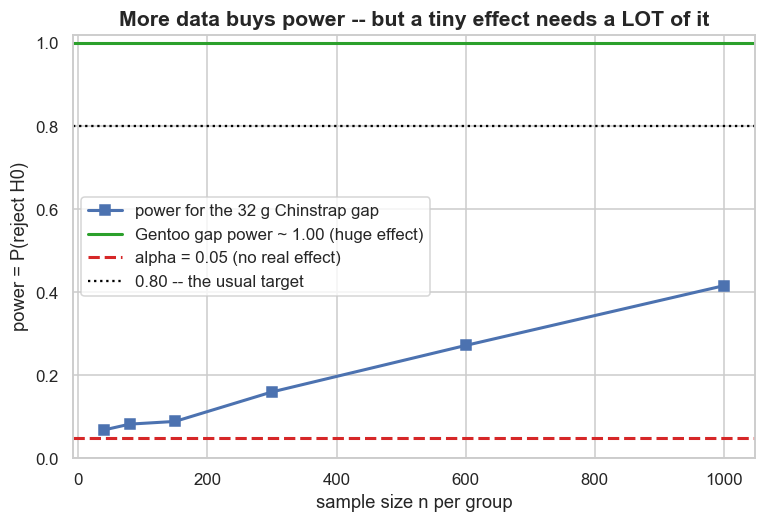

  n =   40 per group  ->  power = 0.069
  n =   80 per group  ->  power = 0.083
  n =  150 per group  ->  power = 0.089
  n =  300 per group  ->  power = 0.160
  n =  600 per group  ->  power = 0.272
  n = 1000 per group  ->  power = 0.416


In [13]:
sizes = [40, 80, 150, 300, 600, 1000]
power_by_n = [power_estimate(adelie, chinstrap, nn, seed=10 + i) for i, nn in enumerate(sizes)]

fig, ax = plt.subplots()
ax.plot(sizes, power_by_n, 's-', color='#4c72b0', lw=2, label='power for the 32 g Chinstrap gap')
ax.axhline(power_AG, color='#2ca02c', ls='-', lw=2, label=f'Gentoo gap power ~ {power_AG:.2f} (huge effect)')
ax.axhline(0.05, color='#d62728', ls='--', lw=2, label='alpha = 0.05 (no real effect)')
ax.axhline(0.80, color='black', ls=':', lw=1.5, label='0.80 -- the usual target')
ax.set_xlabel('sample size n per group')
ax.set_ylabel('power = P(reject H0)')
ax.set_title('More data buys power -- but a tiny effect needs a LOT of it')
ax.set_ylim(0, 1.02); ax.legend(); plt.show()

for nn, pw in zip(sizes, power_by_n):
    print(f'  n = {nn:4d} per group  ->  power = {pw:.3f}')

The huge Gentoo effect already lives at the top of the chart (power $\approx 1$) at every sample size.
The tiny Chinstrap effect starts near the false-alarm floor and only crawls upward — you'd need *hundreds*
of penguins per group to reliably detect a 32 g difference, if it's even real. **Bigger true effect and
bigger $n$ both push power up; a small effect with small $n$ leaves you nearly blind.**

## Now you try

Predict first, then change a number and re-run:

1. **Swap the comparison.** In section 3, build `null_CG = permutation_null(chinstrap, gentoo, seed=4)`
   and compute its p-value against `chinstrap.mean() - gentoo.mean()`. Will Chinstrap-vs-Gentoo land in
   the "reject" or "fail to reject" camp? Predict, then check.
2. **Tighten the threshold.** Re-run section 6 with `alpha = 0.01`. Does the measured false-alarm rate
   fall toward 0.01? Does the red shaded slice in the p-value histogram shrink?
3. **Split a different species.** In section 6, call `type_I_rate(gentoo, ...)` instead of `adelie`. The
   null is still true by construction, so the false-alarm rate should still hover near $\alpha$ — confirm
   it doesn't depend on which species you pick.
4. **Find the break-even n.** In section 7, change `n_each` and find roughly the sample size at which the
   Chinstrap gap reaches power 0.80. Compare it to the ~40 penguins we actually have of each — could this
   data ever have caught a 32 g difference?

## What you learned

- A test pits a precise **null $H_0$** ("the two species weigh the same") against an **alternative $H_a$**
  ("they differ"); you presume the null and ask whether the data is too surprising to keep it.
- The **null world** can be built straight from real data by a **permutation test**: pool both groups,
  shuffle the labels, and recompute the gap thousands of times — no bell curve assumed.
- The **p-value** is the share of that null world at least as extreme as your observed gap. Adelie vs
  Chinstrap gave $p \approx 0.59$ → **fail to reject**; Adelie vs Gentoo gave $p \approx 0$ → **reject** —
  a real near-null and a real effect, side by side, and the textbook **Welch t-test** agreed with both.
- A p-value is **surprise under the null**, *not* the probability $H_0$ is true and *not* an effect size;
  **"fail to reject" never means "proven the same."**
- **Type I error** (false alarm) happens at rate **$\alpha$** — we *measured* about **5%** by repeatedly
  testing one species split randomly against itself, and saw the tell-tale **flat** distribution of
  p-values under a true null.
- **Power $= 1 - \beta$** is the chance of catching a real difference; it was $\approx 100\%$ for the huge
  Gentoo gap and barely above the 5% floor for the tiny Chinstrap gap — **bigger effect and bigger $n$
  mean more power**, and low power is why a small real difference can hide behind "fail to reject."

---

**↩ Back to the lesson:** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](13-hypothesis-testing~the-code.ipynb)